# Langgraph Batasan Iterasi

In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph, END, START
from langchain_ollama import ChatOllama
from langchain_core.messages import HumanMessage
from langchain_core.tools import tool

In [ ]:
# Setup LLM
llm_langgraph = ChatOllama(
    model="qwen3:0.6b-q4_K_M",
    temperature=0.7
)

# Define tools
@tool
def search_tool(query: str) -> str:
    """Search for information"""
    return f"Search results for: {query}"

@tool
def calculator_tool(expression: str) -> str:
    """Calculate mathematical expression"""
    try:
        result = eval(expression)
        return f"Result: {result}"
    except:
        return "Invalid expression"

# Define State
class AgentState(TypedDict):
    messages: list
    iteration_count: int # pembatasan iterasi
    final_answer: str

# Create nodes
def researcher_node(state: AgentState):
    """Researcher agent node"""
    messages = state["messages"]
    response = llm_langgraph.invoke([
        {"role": "system", "content": "You are a researcher. Search for information and provide findings."},
        *messages
    ])
    
    return {
        "messages": messages + [response],
        "iteration_count": state.get("iteration_count", 0) + 1
    }

def analyzer_node(state: AgentState):
    """Analyzer agent node"""
    messages = state["messages"]
    response = llm_langgraph.invoke([
        {"role": "system", "content": "You are an analyzer. Analyze the information and provide insights."},
        *messages
    ])
    
    return {
        "messages": messages + [response],
        "iteration_count": state.get("iteration_count", 0) + 1
    }

def should_continue(state: AgentState) -> str:
    """Router function - controls iteration"""
    # Batasi iterasi di sini
    if state.get("iteration_count", 0) >= 5:  # MAX 5 iterations
        return "end"
    
    last_message = state["messages"][-1].content.lower()
    
    if "final answer" in last_message or "conclusion" in last_message:
        return "end"
    
    return "continue"

# Build LangGraph
def create_langgraph_workflow():
    workflow = StateGraph(AgentState)
    
    # Add nodes
    workflow.add_node("researcher", researcher_node)
    workflow.add_node("analyzer", analyzer_node)
    
    # Add edges
    workflow.add_edge(START, "researcher")
    workflow.add_edge("researcher", "analyzer")
    
    # Conditional edge with iteration control
    workflow.add_conditional_edges(
        "analyzer",
        should_continue,
        {
            "continue": "researcher",
            "end": END
        }
    )
    
    return workflow.compile()


In [3]:
graph = create_langgraph_workflow()

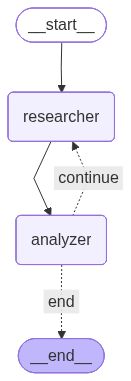

In [4]:
from IPython.display import display, Image
display(Image(graph.get_graph().draw_mermaid_png()))

In [5]:
initial_state = {
    "messages": [HumanMessage(content="Research about AI agents and their applications")],
    "iteration_count": 0,
    "final_answer": ""
}

# Execute with recursion limit
result = graph.invoke(
    initial_state,
    {"recursion_limit": 10}  # Batasan tambahan di level graph
)

print("LangGraph Result:")
print(f"Total iterations: {result['iteration_count']}")
print(f"Final message: {result['messages'][-1].content}")

LangGraph Result:
Total iterations: 2
Final message:  As research continues, the integration of AI agents into daily life will likely redefine our work and personal lives.

This analysis provides a comprehensive overview of AI agents' applications and considerations, emphasizing their potential and the need for responsible innovation.
</think>

AI agents, or autonomous systems, have a vast array of applications across various industries, driven by their ability to analyze, learn, and make decisions. Here’s a structured overview of their key research areas, applications, and considerations:

---

### **1. Healthcare and Medicine**
- **Medical Imaging**: AI agents analyze X-rays, MRIs, and other medical images to detect diseases like cancer with high accuracy. For example, AI-powered tools identify tumors in breast cancer patients with 99% accuracy.
- **Genetic Analysis**: AI predicts drug responses, enabling personalized medicine. This reduces side effects and improves treatment outcome